# Adult Census Income: cross-validation и сравнение моделей

На этом этапе выполняется кросс-валидация для всех обученных моделей и сравнение по нескольким метрикам качества

Что входит в этот этап:

- **кросс-валидация** (stratified 5-fold) для каждой модели
- **множественные метрики**: accuracy, F1-score, balanced_accuracy, ROC-AUC
- **сравнение моделей** в едином DataFrame
- **визуализация** результатов
- **выбор лучших кандидатов** не только по accuracy, а с учётом компромиссов между метриками

## Импорты и настройки

In [8]:
import os

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

import sys
from pathlib import Path

sys.path.append(str(Path.cwd()))
sys.path.append(str(Path.cwd() / "src"))

from adult_income_utils import (
    RANDOM_STATE,
    add_features,
    get_feature_lists,
    load_clean_adult_data,
    make_X_y,
    make_preprocessor,
)

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## Подготовка данных

In [9]:
from sklearn.model_selection import train_test_split

df_clean = load_clean_adult_data()
df_features = add_features(df_clean)

X, y = make_X_y(df_features)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

numerical_features, categorical_features = get_feature_lists(X_train)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True))

X_train shape: (39032, 21)
X_test shape: (9758, 21)
y_train distribution:
income
0    0.760581
1    0.239419
Name: proportion, dtype: float64


## Стратегия кросс-валидации

Для честного сравнения всех моделей используем `StratifiedKFold` с 5 разбиениями.

**Почему StratifiedKFold?**

- Сохраняет распределение классов в каждом fold;
- Критически важно для несбалансированных датасетов (как Adult Income);
- Обеспечивает стабильные оценки качества.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"StratifiedKFold: {cv.get_n_splits()} splits")
print(f"Random state: {RANDOM_STATE}")

StratifiedKFold: 5 splits
Random state: 42


## Определение моделей и scoring метрик

Используем ту же комбинацию моделей:

- `DummyClassifier(strategy="most_frequent")` как baseline
- `LogisticRegression` с `class_weight="balanced"`
- `KNeighborsClassifier` как простая non-linear модель
- `DecisionTreeClassifier` как интерпретируемая модель
- `RandomForestClassifier` как ансамбль деревьев
- `GradientBoostingClassifier` как мощный ансамбль

**Scoring метрики:**

- `accuracy`: доля правильных предсказаний 
- `f1`: гармоническое среднее precision и recall
- `balanced_accuracy`: среднее recall для каждого класса 
- `roc_auc`: площадь под ROC-кривой

In [11]:
models = {
    "DummyClassifier": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
    ),
    "RandomForest": RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
    ),
    "GradientBoosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE,
    ),
}

scoring_metrics = {
    "accuracy": "accuracy",
    "f1": "f1",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc": "roc_auc",
}

print(f"Моделей для сравнения: {len(models)}")
print(f"Scoring метрик: {len(scoring_metrics)}")
print(f"\nМодели:")
for model_name in models.keys():
    print(f"  - {model_name}")

Моделей для сравнения: 6
Scoring метрик: 4

Модели:
  - DummyClassifier
  - LogisticRegression
  - KNN
  - DecisionTree
  - RandomForest
  - GradientBoosting


## Кросс-валидация всех моделей

Для каждой модели:

1. Создаём Pipeline с preprocessing и моделью
2. Выполняем cross_validate с StratifiedKFold
3. Собираем результаты для каждой метрики

In [12]:
cv_results = {}

for model_name, model in models.items():
    print(f"Cross-validation for {model_name}...", end=" ")

    preprocessor = make_preprocessor(numerical_features, categorical_features)
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    cv_results[model_name] = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring_metrics,
        return_train_score=False,
        n_jobs=-1,
    )

    print("✓")

print("\nCross-validation completed.")

Cross-validation for DummyClassifier... ✓
Cross-validation for LogisticRegression... ✓
Cross-validation for KNN... ✓
Cross-validation for DecisionTree... ✓
Cross-validation for RandomForest... ✓
Cross-validation for GradientBoosting... ✓

Cross-validation completed.


## Сборка результатов в единую таблицу

Из результатов кросс-валидации извлекаем средние и стандартные отклонения для каждой метрики

In [22]:

results_data = []

for model_name, cv_result in cv_results.items():
    row = {"Model": model_name}

    for metric in scoring_metrics.keys():
        test_scores = cv_result[f"test_{metric}"]
        row[f"{metric}_mean"] = test_scores.mean()
        row[f"{metric}_std"] = test_scores.std()

    results_data.append(row)

results_df = pd.DataFrame(results_data)

metric_cols = []
for metric in scoring_metrics.keys():
    metric_cols.extend([f"{metric}_mean", f"{metric}_std"])

results_df = results_df[["Model"] + metric_cols]
results_df

,Model,accuracy_mean,accuracy_std,f1_mean,f1_std,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std
0,DummyClassifier,0.760581,0.000015,0.000000,0.000000,0.500000,0.000000,0.500000,0.000000
1,LogisticRegression,0.813563,0.003704,0.685378,0.006937,0.825451,0.006282,0.910281,0.005226
2,KNN,0.836288,0.003915,0.645078,0.010813,0.762740,0.007661,0.862365,0.004588
3,DecisionTree,0.813102,0.004620,0.611962,0.008243,0.745407,0.005358,0.745418,0.005342
4,RandomForest,0.853659,0.002235,0.664943,0.006718,0.769026,0.004789,0.902528,0.004618
5,GradientBoosting,0.865085,0.004314,0.681777,0.011186,0.775548,0.006888,0.920185,0.004817


## Средние значения метрик (rounded)

Для удобства анализа показываем средние значения с округлением до 3 знаков после запятой.

In [31]:
results_means = results_df[["Model", "accuracy_mean", "f1_mean", "balanced_accuracy_mean", "roc_auc_mean"]].copy()
results_means.columns = ["Model", "Accuracy", "F1", "Balanced Accuracy", "ROC-AUC"]
results_means = results_means.set_index("Model")

print("\n=== Средние значения метрик (5-fold CV) ===")
print(results_means.round(4))

results_summary = results_means


=== Средние значения метрик (5-fold CV) ===
                    Accuracy      F1  Balanced Accuracy  ROC-AUC
Model                                                           
DummyClassifier       0.7606  0.0000             0.5000   0.5000
LogisticRegression    0.8136  0.6854             0.8255   0.9103
KNN                   0.8363  0.6451             0.7627   0.8624
DecisionTree          0.8131  0.6120             0.7454   0.7454
RandomForest          0.8537  0.6649             0.7690   0.9025
GradientBoosting      0.8651  0.6818             0.7755   0.9202


## Ранжирование моделей по каждой метрике

Для каждой метрики создаем ранжирование (1 = лучшая, 6 = худшая)

In [40]:
rankings = pd.DataFrame(index=results_summary.index)

for metric in results_summary.columns:
    rankings[f"{metric}_rank"] = results_summary[metric].rank(ascending=False).astype(int)

print("\n=== Ранжирование моделей (1=лучшая) ===")
print(rankings)


=== Ранжирование моделей (1=лучшая) ===
                    Accuracy_rank  F1_rank  Balanced Accuracy_rank  \
Model                                                                
DummyClassifier                 6        6                       6   
LogisticRegression              4        1                       1   
KNN                             3        4                       4   
DecisionTree                    5        5                       5   
RandomForest                    2        3                       3   
GradientBoosting                1        2                       2   

                    ROC-AUC_rank  
Model                             
DummyClassifier                6  
LogisticRegression             2  
KNN                            4  
DecisionTree                   5  
RandomForest                   3  
GradientBoosting               1  


## Лучшие модели по каждой метрике

In [41]:
print("\n=== Лучшие модели по каждой метрике ===")

for metric in results_summary.columns:
    best_model = results_summary[metric].idxmax()
    best_score = results_summary[metric].max()
    print(f"{metric:20} -> {best_model:20} ({best_score:.4f})")


=== Лучшие модели по каждой метрике ===
Accuracy             -> GradientBoosting     (0.8651)
F1                   -> LogisticRegression   (0.6854)
Balanced Accuracy    -> LogisticRegression   (0.8255)
ROC-AUC              -> GradientBoosting     (0.9202)


## Анализ компромиссов между метриками

Создаётся обобщённый рейтинг, усредняющий ранги каждой модели по всем метрикам.

In [42]:
rankings["mean_rank"] = rankings.mean(axis=1)
rankings = rankings.sort_values("mean_rank")

print("\n=== Средний ранг (1 = лучше) ===")
print(rankings[["mean_rank"]].round(2))


=== Средний ранг (1 = лучше) ===
                    mean_rank
Model                        
GradientBoosting         1.50
LogisticRegression       2.00
RandomForest             2.75
KNN                      3.75
DecisionTree             5.00
DummyClassifier          6.00


## Выбор лучших кандидатов

Выбираем 2 лучшие модели для дальнейшей оптимизации в GridSearchCV.

Критерии выбора:
- Хороший средний ранг по всем метрикам
- Баланс между accuracy, F1 и ROC-AUC 
- Не прерывиать baseline 

In [43]:
# Выбираем топ-2 модели (исключая baseline)
top_models = rankings.sort_values("mean_rank").head(2)
top_model_names = top_models.index.tolist()

# Если в топ-2 попадает baseline - берём топ-3 и исключаем baseline
if "DummyClassifier" in top_model_names:
    top_models = rankings[rankings.index != "DummyClassifier"].sort_values("mean_rank").head(2)
    top_model_names = top_models.index.tolist()

print("\n" + "="*60)
print("ВЫБОР ЛУЧШИХ КАНДИДАТОВ ДЛЯ ГИПЕРПАРАМЕТРИЧЕСКОЙ ОПТИМИЗАЦИИ")
print("="*60)

for i, model_name in enumerate(top_model_names, 1):
    print(f"\nТоп-{i}: {model_name}")
    print(f"  Средний ранг: {top_models.loc[model_name, 'mean_rank']:.2f}")
    print(f"  Accuracy:        {results_summary.loc[model_name, 'Accuracy']:.4f}")
    print(f"  F1:              {results_summary.loc[model_name, 'F1']:.4f}")
    print(f"  Balanced Acc:    {results_summary.loc[model_name, 'Balanced Accuracy']:.4f}")
    print(f"  ROC-AUC:         {results_summary.loc[model_name, 'ROC-AUC']:.4f}")

print("\n" + "="*60)


ВЫБОР ЛУЧШИХ КАНДИДАТОВ ДЛЯ ГИПЕРПАРАМЕТРИЧЕСКОЙ ОПТИМИЗАЦИИ

Топ-1: GradientBoosting
  Средний ранг: 1.50
  Accuracy:        0.8651
  F1:              0.6818
  Balanced Acc:    0.7755
  ROC-AUC:         0.9202

Топ-2: LogisticRegression
  Средний ранг: 2.00
  Accuracy:        0.8136
  F1:              0.6854
  Balanced Acc:    0.8255
  ROC-AUC:         0.9103



##  Сравнение по каждой метрике
Зеленая это лучшая

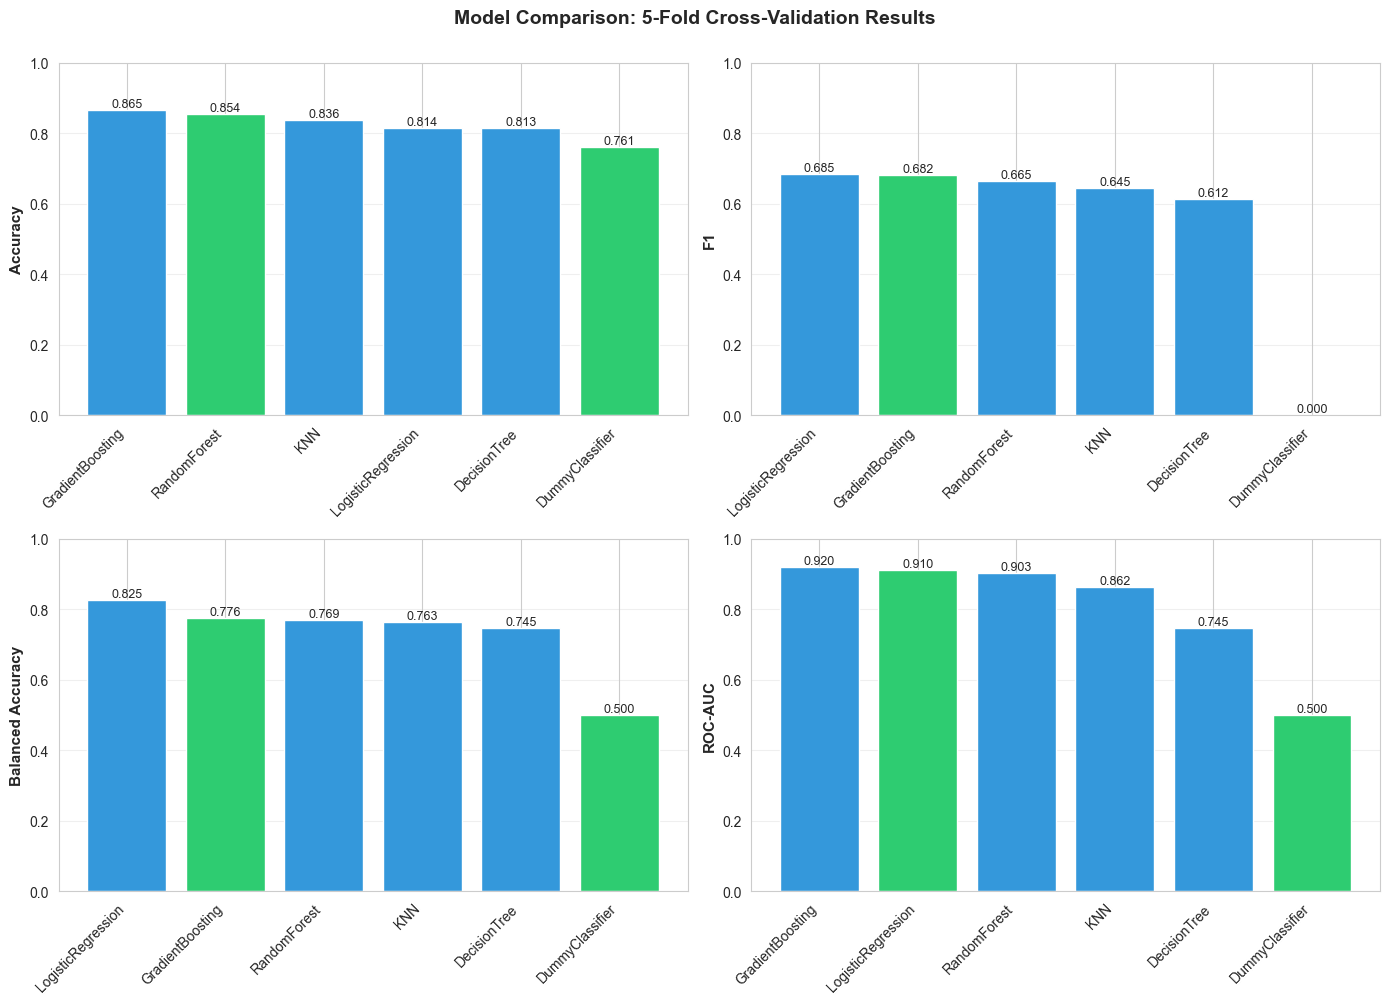

Зелёные столбцы указывают на выбранные лучшие модели.


In [44]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics = ["Accuracy", "F1", "Balanced Accuracy", "ROC-AUC"]
colors = ["#2ecc71" if model in top_model_names else "#3498db" 
          for model in results_summary.index]

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    sorted_data = results_summary[metric].sort_values(ascending=False)
    bars = ax.bar(range(len(sorted_data)), sorted_data.values, color=colors)
    ax.set_xticks(range(len(sorted_data)))
    ax.set_xticklabels(sorted_data.index, rotation=45, ha="right")
    ax.set_ylabel(metric, fontsize=11, fontweight="bold")
    ax.set_ylim([0, 1])
    ax.grid(axis="y", alpha=0.3)
    
    # Добавляем значения на столбцы
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle("Model Comparison: 5-Fold Cross-Validation Results", 
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

## Heatmap ранжирования

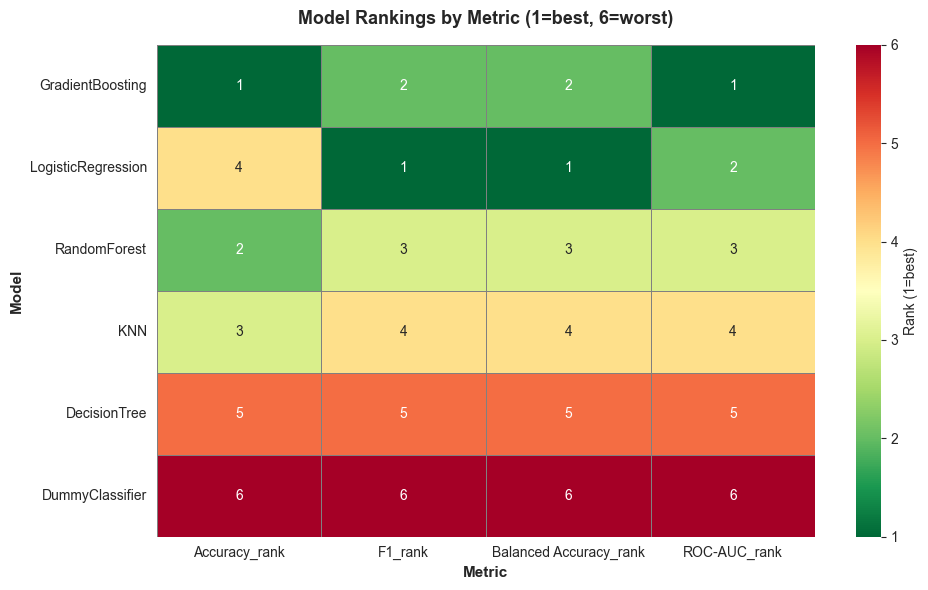

In [45]:
plt.figure(figsize=(10, 6))

rank_data = rankings.drop("mean_rank", axis=1)
sns.heatmap(rank_data, annot=True, fmt="d", cmap="RdYlGn_r", 
            cbar_kws={"label": "Rank (1=best)"},
            linewidths=0.5, linecolor="gray")

plt.title("Model Rankings by Metric (1=best, 6=worst)", 
          fontsize=13, fontweight="bold", pad=15)
plt.ylabel("Model", fontsize=11, fontweight="bold")
plt.xlabel("Metric", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

## Сохранение результатов для следующего этапа


In [38]:
# Сохраняем всю таблицу результатов
results_export = results_summary.copy()
results_export["mean_rank"] = rankings["mean_rank"]
results_export.to_csv("../data/model_comparison_results.csv")

# Сохраняем список лучших моделей
best_models_info = {
    "top_models": top_model_names,
    "top_1": top_model_names[0],
    "top_2": top_model_names[1],
}

import json
with open("../data/best_models.json", "w") as f:
    json.dump(best_models_info, f, indent=2)

print("Results saved:")
print("  - ../data/model_comparison_results.csv")
print("  - ../data/best_models.json")
print(f"\nТоп модели для гиперпараметрической оптимизации:")
print(f"  1. {top_model_names[0]}")
print(f"  2. {top_model_names[1]}")

Results saved:
  - ../data/model_comparison_results.csv
  - ../data/best_models.json

Топ модели для гиперпараметрической оптимизации:
  1. GradientBoosting
  2. LogisticRegression


## Итоги этапа

На этом этапе выполнены следующие задачи:

✓ **Кросс-валидация** всех 6 моделей с использованием StratifiedKFold (5 folds);

✓ **Оценка качества** по 4 метрикам: accuracy, F1, balanced_accuracy, ROC-AUC;

✓ **Анализ компромиссов** между метриками, выбор моделей, которые хорошо работают не по одной, а по совокупности критериев;

✓ **Визуализация** результатов (bar plots и heatmap рангов);

✓ **Выбор лучших кандидатов** для гиперпараметрической оптимизации в следующем notebook.
